In [1]:
import pandas as pd
import time
import numpy as np
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (recall_score, precision_score, f1_score, 
                             accuracy_score, roc_auc_score, average_precision_score, 
                             confusion_matrix)
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, RandomOverSampler
from sklearn.cluster import MiniBatchKMeans

## Opis kroków przeprowadzonych podczas estymacji oraz walidacji modelu Regresji Logistycznej:
### Wczytanie danych
Dane na których został wytrenowany oraz zwalidowany model Regresji Logistycznej to dane, dla których została przeprowadzaona Ekspolarcyjna Analiza Danych oraz Inżynieria Cech w Notebooku `00_EAD`.
Wczytane dane zostały już wcześniej podzielone na zbiór treningowy oraz testowy w proporcji 30/70.

### Transformacja danych
Następnie została przeprowadzona transformacja danych:
- One-Hot Encoding: zmienna określająca rodzaj transakcji `type` jest zmienną kategoryczną. Matemtyczny model regresji logistycznej wymaga danych numeryczny, podobnie jak użyte samplery opare na odległościach. 
- RobustScaler: podobnie jak w przypadku zastosowania metody One-Hot Encoding, regresja logistyczna jak i samplery oprate na odległości wymagają danych, które mają taką samą skale.
Jako skaler użuto RobustSkaler, który jest bardziej odporny na wartości odstające, które występują w danych finansowych. Został on zastosowany do wszystkich kolumn, poza kolumnami 0/1.

$$X_{scaled} = \frac{X - \text{median}(X)}{IQR(X)} = \frac{X - \text{median}(X)}{Q_3(X) - Q_1(X)}$$

* $\text{median}(X)$ – medianę dla danej cechy wyliczoną z całego zbioru treningowego.
* $IQR(X)$ – rozstęp międzykwartylowy, będący miarą rozproszenia danych.
* $Q_1(X)$ – pierwszy kwartyl,
* $Q_3(X)$ – trzeci kwartyl,

### Słownik sampletrów
W następnym bloku zdefiniowano słownik `samplers` przygotowujący środowisko do eksperymentów z balansowaniem klas. 
Skrypt iteracyjnie generuje zestaw obejmujący wariant bazowy oraz 6 algorytmów: RandomUnderSampler, Cluster Centroids, RandomOverSampler, SMOTE, Borderline-SMOTE, ADASYN. 
Każda z metod jest inicjalizowana dla 4 różnych docelowych proporcji klasy mniejszościowej: 0.25, 0.50, 0.75 oraz 'auto' (1:1).

### Główna pętla
Finalnie uruchamiana jest główna pętla eksperymentu. 
Kod iteruje przez zdefiniowany wcześniej słownik samplerów, przekształcając zbiór treningowy i trenując na nim standardowy model Regresji Logistycznej. 
Następnie trenowany jest osobny model wykorzystujący wbudowane ważenie klas `class_weight='balanced'`, testując podejście na poziomie algorytmu. 
Dla każdego wariantu obliczane są kluczowe metryki na zbiorze treningowym jak i testowym.

### Analiza przesunięcia ważności cech
Następnie została przprowadzona analiza ważności cech dla wybranych metod. 


### Wczytanie danych

In [2]:
X_train = pd.read_parquet('gotowe_dane/X_train.parquet')
X_test = pd.read_parquet('gotowe_dane/X_test.parquet')
y_train = pd.read_parquet('gotowe_dane/y_train.parquet')['isFraud']
y_test = pd.read_parquet('gotowe_dane/y_test.parquet')['isFraud']

print(f"Kształt zbioru treningowego: {X_train.shape}")

Kształt zbioru treningowego: (4453834, 7)


In [3]:
X_train.head()

,type,amount,balanceRatioOrig,balanceRatioDest,isErrorOrig,isErrorDest,hour
4310249,CASH_IN,260485.23,-8.046868,-5.621708e-02,1,1,20
318938,TRANSFER,1387060.19,1.000000,1.033441e+08,1,1,16
3375139,TRANSFER,1140661.98,1.000000,7.603977e+01,1,0,14
5492781,CASH_IN,169390.39,-2.116134,-1.154641e-01,1,1,20
807263,CASH_IN,4867.26,-0.000813,-3.024298e-03,1,1,16


### Transformacja danych

In [4]:
# One-Hot Encoding dla kolumny kategorycznej
X_train_ohe = pd.get_dummies(X_train, columns=['type'], drop_first=True, dtype=int)
X_test_ohe = pd.get_dummies(X_test, columns=['type'], drop_first=True, dtype=int)

# Zbieramy kolumny numeryczne
num_cols = [col for col in X_train.columns if col != 'type']

X_train_scaled = X_train_ohe.copy()
X_test_scaled = X_test_ohe.copy()

# RobustScaler tylko na kolumnach numerycznych, z pominięciem kolumn 0/1
scaler = RobustScaler()
X_train_scaled[num_cols] = scaler.fit_transform(X_train_ohe[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_ohe[num_cols])

### Definiowanie słownika samplerów

In [5]:
proporcje = [0.25, 0.5, 0.75, 'auto']

samplers = {'Brak (Baseline)': None}

for p in proporcje:
    nazwa_p = str(p)
    
    samplers[f'RUS ({nazwa_p})'] = RandomUnderSampler(sampling_strategy=p, random_state=42)
    samplers[f'ROS ({nazwa_p})'] = RandomOverSampler(sampling_strategy=p, random_state=42)
    samplers[f'SMOTE ({nazwa_p})'] = SMOTE(sampling_strategy=p, random_state=42)
    samplers[f'Borderline-SMOTE ({nazwa_p})'] = BorderlineSMOTE(sampling_strategy=p, random_state=42)
    samplers[f'ADASYN ({nazwa_p})'] = ADASYN(sampling_strategy=p, random_state=42)
    samplers[f'Cluster Centroids ({nazwa_p})'] = ClusterCentroids(
        sampling_strategy=p,
        estimator=MiniBatchKMeans(n_init=1, random_state=42), 
        random_state=42
    )


### Główna pętla

### Pierwsze podejście (próg odcięcia standardowy - 0.5)

In [6]:
model_standard = LogisticRegression(max_iter=1000, random_state=42)
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

results_test = []
results_train = [] # Dodana osobna lista dla wyników treningowych
print("--- ROZPOCZĘCIE EKSPERYMENTU: REGRESJA LOGISTYCZNA ---\n")
for s_name, sampler in samplers.items():
    print(f" -> Trenuję: Regresja Logistyczna + {s_name}")

    # timer dla samplera
    start_sampler = time.time()
    if sampler:
        X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    else:
        X_res, y_res = X_train_scaled, y_train
    end_sampler = time.time()
    czas_samplera = end_sampler - start_sampler
    
    # timer dla modelu
    start_model = time.time()
    model_standard.fit(X_res, y_res)
    end_model = time.time()
    czas_modelu = end_model - start_model
    
    czas_calkowity = czas_samplera + czas_modelu
    
    # ZBIÓR TESTOWY
    preds_test = model_standard.predict(X_test_scaled)
    preds_proba_test = model_standard.predict_proba(X_test_scaled)[:, 1]
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, preds_test).ravel()
    
    # ZBIÓR TRENINGOWY
    preds_train = model_standard.predict(X_train_scaled)
    preds_proba_train = model_standard.predict_proba(X_train_scaled)[:, 1]
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, preds_train).ravel()
    
    # ZAPIS DO TABELI TESTOWEJ
    results_test.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_test, preds_test),
        'Precision (Precyzja)': precision_score(y_test, preds_test),
        'F1-Score': f1_score(y_test, preds_test),
        'ROC-AUC': roc_auc_score(y_test, preds_proba_test),
        'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test),
        'Accuracy': accuracy_score(y_test, preds_test),
        'Fałszywe Alarmy (FP)': fp_test,
        'Przegapione Oszustwa (FN)': fn_test
    })

    # ZAPIS DO TABELI TRENINGOWEJ
    results_train.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_train, preds_train),
        'Precision (Precyzja)': precision_score(y_train, preds_train),
        'F1-Score': f1_score(y_train, preds_train),
        'ROC-AUC': roc_auc_score(y_train, preds_proba_train),
        'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train),
        'Accuracy': accuracy_score(y_train, preds_train),
        'Fałszywe Alarmy (FP)': fp_train,
        'Przegapione Oszustwa (FN)': fn_train
    })

# wewnętrzne ważenie klas
print(" -> Trenuję: Regresja Logistyczna + class_weight='balanced'")

czas_samplera_w = 0.0

start_model_w = time.time()
model_weighted.fit(X_train_scaled, y_train)
end_model_w = time.time()
czas_modelu_w = end_model_w - start_model_w
czas_calkowity_w = czas_samplera_w + czas_modelu_w

# ZBIÓR TESTOWY
preds_test_w = model_weighted.predict(X_test_scaled)
preds_proba_test_w = model_weighted.predict_proba(X_test_scaled)[:, 1]
tn_test_w, fp_test_w, fn_test_w, tp_test_w = confusion_matrix(y_test, preds_test_w).ravel()

# ZBIÓR TRENINGOWY
preds_train_w = model_weighted.predict(X_train_scaled)
preds_proba_train_w = model_weighted.predict_proba(X_train_scaled)[:, 1]
tn_train_w, fp_train_w, fn_train_w, tp_train_w = confusion_matrix(y_train, preds_train_w).ravel()

results_test.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Ważenie Klas',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_test, preds_test_w),
    'Precision (Precyzja)': precision_score(y_test, preds_test_w),
    'F1-Score': f1_score(y_test, preds_test_w),
    'ROC-AUC': roc_auc_score(y_test, preds_proba_test_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test_w),
    'Accuracy': accuracy_score(y_test, preds_test_w),
    'Fałszywe Alarmy (FP)': fp_test_w,
    'Przegapione Oszustwa (FN)': fn_test_w
})

results_train.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Ważenie Klas',
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_train, preds_train_w),
    'Precision (Precyzja)': precision_score(y_train, preds_train_w),
    'F1-Score': f1_score(y_train, preds_train_w),
    'ROC-AUC': roc_auc_score(y_train, preds_proba_train_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train_w),
    'Accuracy': accuracy_score(y_train, preds_train_w),
    'Fałszywe Alarmy (FP)': fp_train_w,
    'Przegapione Oszustwa (FN)': fn_train_w
})

print("\n--- ZAKOŃCZONO ---")

results_df_train = pd.DataFrame(results_train)
results_df_test = pd.DataFrame(results_test)

nazwa_pliku_train = 'wyniki_regresja_logistyczna_train.csv'
nazwa_pliku_test = 'wyniki_regresja_logistyczna_test.csv'

results_df_train.to_csv(nazwa_pliku_train, index=False)
results_df_test.to_csv(nazwa_pliku_test, index=False)

print(f"Wyniki treningowe zostały pomyślnie zapisane do pliku: {nazwa_pliku_train}")
print(f"Wyniki testowe zostały pomyślnie zapisane do pliku: {nazwa_pliku_test}")

--- ROZPOCZĘCIE EKSPERYMENTU: REGRESJA LOGISTYCZNA ---

 -> Trenuję: Regresja Logistyczna + Brak (Baseline)
 -> Trenuję: Regresja Logistyczna + RUS (0.25)
 -> Trenuję: Regresja Logistyczna + ROS (0.25)
 -> Trenuję: Regresja Logistyczna + SMOTE (0.25)
 -> Trenuję: Regresja Logistyczna + Borderline-SMOTE (0.25)
 -> Trenuję: Regresja Logistyczna + ADASYN (0.25)
 -> Trenuję: Regresja Logistyczna + Cluster Centroids (0.25)
 -> Trenuję: Regresja Logistyczna + RUS (0.5)
 -> Trenuję: Regresja Logistyczna + ROS (0.5)
 -> Trenuję: Regresja Logistyczna + SMOTE (0.5)
 -> Trenuję: Regresja Logistyczna + Borderline-SMOTE (0.5)
 -> Trenuję: Regresja Logistyczna + ADASYN (0.5)
 -> Trenuję: Regresja Logistyczna + Cluster Centroids (0.5)
 -> Trenuję: Regresja Logistyczna + RUS (0.75)
 -> Trenuję: Regresja Logistyczna + ROS (0.75)
 -> Trenuję: Regresja Logistyczna + SMOTE (0.75)
 -> Trenuję: Regresja Logistyczna + Borderline-SMOTE (0.75)
 -> Trenuję: Regresja Logistyczna + ADASYN (0.75)
 -> Trenuję: Regr

In [7]:
display(results_df_train)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Brak (Baseline),0.00,21.16,21.16,0.000000,0.000000,0.000000,0.374574,0.001225,0.998682,119,5749
1,Data-Level,RUS (0.25),0.63,0.26,0.88,0.708993,0.005518,0.010950,0.879482,0.019737,0.834679,734639,1673
2,Data-Level,ROS (0.25),1.23,17.96,19.18,0.997217,0.002512,0.005011,0.913576,0.010256,0.488826,2276666,16
3,Data-Level,SMOTE (0.25),1.09,15.41,16.50,0.997217,0.002516,0.005019,0.915438,0.010375,0.489673,2272894,16
4,Data-Level,Borderline-SMOTE (0.25),5.66,16.48,22.13,0.997391,0.002435,0.004858,0.911846,0.010086,0.472529,2349253,15
5,Data-Level,ADASYN (0.25),5.36,21.52,26.88,0.997217,0.002612,0.005211,0.909554,0.009897,0.508557,2188791,16
6,Data-Level,Cluster Centroids (0.25),290.44,0.14,290.58,0.900678,0.002491,0.004969,0.858785,0.035870,0.534350,2073357,571
7,Data-Level,RUS (0.5),0.64,0.14,0.78,0.997565,0.002236,0.004461,0.913276,0.010226,0.425319,2559522,14
8,Data-Level,ROS (0.5),1.53,40.16,41.69,0.996347,0.002898,0.005779,0.931058,0.023763,0.557448,1971034,21
9,Data-Level,SMOTE (0.5),1.47,19.11,20.58,0.997565,0.002298,0.004586,0.932303,0.022812,0.441029,2489548,14


In [8]:
display(results_df_test)

,Podejście,Metoda,Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Brak (Baseline),0.00,21.16,21.16,0.000406,0.015152,0.000791,0.393503,0.001420,0.998676,65,2463
1,Data-Level,RUS (0.25),0.63,0.26,0.88,0.699675,0.005440,0.010796,0.875285,0.018356,0.834488,315187,740
2,Data-Level,ROS (0.25),1.23,17.96,19.18,0.995942,0.002509,0.005006,0.913164,0.010530,0.488952,975472,10
3,Data-Level,SMOTE (0.25),1.09,15.41,16.50,0.995942,0.002514,0.005015,0.915085,0.010650,0.489841,973774,10
4,Data-Level,Borderline-SMOTE (0.25),5.66,16.48,22.13,0.996347,0.002432,0.004853,0.911235,0.010349,0.472522,1006833,9
5,Data-Level,ADASYN (0.25),5.36,21.52,26.88,0.995942,0.002611,0.005208,0.909126,0.010171,0.508862,937467,10
6,Data-Level,Cluster Centroids (0.25),290.44,0.14,290.58,0.897321,0.002484,0.004955,0.856709,0.033665,0.534793,887727,253
7,Data-Level,RUS (0.5),0.64,0.14,0.78,0.997159,0.002235,0.004459,0.912622,0.010490,0.425239,1097088,7
8,Data-Level,ROS (0.5),1.53,40.16,41.69,0.995536,0.002894,0.005771,0.928146,0.022250,0.557187,845224,11
9,Data-Level,SMOTE (0.5),1.47,19.11,20.58,0.997159,0.002297,0.004584,0.930076,0.021957,0.440960,1067080,7


### Wstępna analiza wyników

Wszystkie analizowane modele charakteryzują się wysoką liczbą wyników fałszywie dodatnich (FP) przy niskiej liczbie wyników fałszywie ujemnych (FN). Dominacja wyników fałszywie dodatnich wynika w dużej mierze z przyjęcia domyślnego progu klasyfikacji na poziomie 0,5. Wartość ta jest znacznie wyższa niż rzeczywisty udział transakcji oszustów w zbiorze treningowym (wynoszący 1%), co w warunkach klasyfikacji niezbalansowanej prowadzi do zawyżenia predykcji klasy mniejszościowej.

Drugie podejście polega na przeprowadzeniu testów z wykorzystaniem dynamicznego progu odcięcia. Podejście to zakłada wyznaczanie indywidualnego progu prawdopodobieństwa dla każdego modelu, w oparciu o proporcję klas w zbiorze treningowym (transakcje poprawne do oszustów), co moze pozwolic na lepsze dopasowanie modelu do charakterystyki danych oraz zbalansowanie kosztów błędów typu I i typu II.

### Drugie podejście (próg odcięcia dynamiczny)

In [9]:
model_standard = LogisticRegression(max_iter=1000, random_state=42)
model_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

results_test = []
results_train = []
print("--- ROZPOCZĘCIE EKSPERYMENTU: REGRESJA LOGISTYCZNA Z DYNAMICZNYM PROGIEM ---\n")

for s_name, sampler in samplers.items():
    print(f" -> Trenuję: Regresja Logistyczna + {s_name}")

    # Timer dla samplera
    start_sampler = time.time()
    if sampler:
        X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    else:
        X_res, y_res = X_train_scaled, y_train
    end_sampler = time.time()
    czas_samplera = end_sampler - start_sampler
    
    # Wyliczenie progu odcięcia jako udokładniony udział klasy 0 w zbiorze po samplingu
    # Używamy pd.Series w razie, gdyby y_res było tablicą numpy
    threshold = pd.Series(y_res).value_counts(normalize=True)[0]
    print(f" -> Próg odcięcia: {threshold}")
    # Timer dla modelu
    start_model = time.time()
    model_standard.fit(X_res, y_res)
    end_model = time.time()
    czas_modelu = end_model - start_model
    
    czas_calkowity = czas_samplera + czas_modelu
    
    # ZBIÓR TESTOWY - prognozowanie z użyciem nowego progu odcięcia
    preds_proba_test = model_standard.predict_proba(X_test_scaled)[:, 1]
    preds_test = (preds_proba_test >= threshold).astype(int)
    tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, preds_test).ravel()
    
    # ZBIÓR TRENINGOWY - prognozowanie z użyciem nowego progu odcięcia
    preds_proba_train = model_standard.predict_proba(X_train_scaled)[:, 1]
    preds_train = (preds_proba_train >= threshold).astype(int)
    tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, preds_train).ravel()
    
    # ZAPIS DO TABELI TESTOWEJ
    results_test.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Próg odcięcia (Threshold)': round(threshold, 4),
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_test, preds_test),
        'Precision (Precyzja)': precision_score(y_test, preds_test),
        'F1-Score': f1_score(y_test, preds_test),
        'ROC-AUC': roc_auc_score(y_test, preds_proba_test),
        'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test),
        'Accuracy': accuracy_score(y_test, preds_test),
        'Fałszywe Alarmy (FP)': fp_test,
        'Przegapione Oszustwa (FN)': fn_test
    })

    # ZAPIS DO TABELI TRENINGOWEJ
    results_train.append({
        'Podejście': 'Data-Level',
        'Metoda': s_name,
        'Próg odcięcia (Threshold)': round(threshold, 4),
        'Czas Samplera (s)': round(czas_samplera, 2),
        'Czas Modelu (s)': round(czas_modelu, 2),
        'Czas Całkowity (s)': round(czas_calkowity, 2),
        'Recall (Czułość)': recall_score(y_train, preds_train),
        'Precision (Precyzja)': precision_score(y_train, preds_train),
        'F1-Score': f1_score(y_train, preds_train),
        'ROC-AUC': roc_auc_score(y_train, preds_proba_train),
        'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train),
        'Accuracy': accuracy_score(y_train, preds_train),
        'Fałszywe Alarmy (FP)': fp_train,
        'Przegapione Oszustwa (FN)': fn_train
    })

# Wewnętrzne ważenie klas (Algorithm-Level)
print(" -> Trenuję: Regresja Logistyczna + class_weight='balanced'")

czas_samplera_w = 0.0

# Dla metody bez samplingu (class_weight), progiem odcięcia jest proporcja klasy 0 w oryginalnym y_train
threshold_w = pd.Series(y_train).value_counts(normalize=True)[0]

start_model_w = time.time()
model_weighted.fit(X_train_scaled, y_train)
end_model_w = time.time()
czas_modelu_w = end_model_w - start_model_w
czas_calkowity_w = czas_samplera_w + czas_modelu_w

# ZBIÓR TESTOWY
preds_proba_test_w = model_weighted.predict_proba(X_test_scaled)[:, 1]
preds_test_w = (preds_proba_test_w >= threshold_w).astype(int)
tn_test_w, fp_test_w, fn_test_w, tp_test_w = confusion_matrix(y_test, preds_test_w).ravel()

# ZBIÓR TRENINGOWY
preds_proba_train_w = model_weighted.predict_proba(X_train_scaled)[:, 1]
preds_train_w = (preds_proba_train_w >= threshold_w).astype(int)
tn_train_w, fp_train_w, fn_train_w, tp_train_w = confusion_matrix(y_train, preds_train_w).ravel()

results_test.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Ważenie Klas',
    'Próg odcięcia (Threshold)': round(threshold_w, 4),
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_test, preds_test_w),
    'Precision (Precyzja)': precision_score(y_test, preds_test_w),
    'F1-Score': f1_score(y_test, preds_test_w),
    'ROC-AUC': roc_auc_score(y_test, preds_proba_test_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_test, preds_proba_test_w),
    'Accuracy': accuracy_score(y_test, preds_test_w),
    'Fałszywe Alarmy (FP)': fp_test_w,
    'Przegapione Oszustwa (FN)': fn_test_w
})

results_train.append({
    'Podejście': 'Algorithm-Level',
    'Metoda': 'Wewnętrzne Ważenie Klas',
    'Próg odcięcia (Threshold)': round(threshold_w, 4),
    'Czas Samplera (s)': round(czas_samplera_w, 2),
    'Czas Modelu (s)': round(czas_modelu_w, 2),
    'Czas Całkowity (s)': round(czas_calkowity_w, 2),
    'Recall (Czułość)': recall_score(y_train, preds_train_w),
    'Precision (Precyzja)': precision_score(y_train, preds_train_w),
    'F1-Score': f1_score(y_train, preds_train_w),
    'ROC-AUC': roc_auc_score(y_train, preds_proba_train_w),
    'Avg Precision (PR-AUC)': average_precision_score(y_train, preds_proba_train_w),
    'Accuracy': accuracy_score(y_train, preds_train_w),
    'Fałszywe Alarmy (FP)': fp_train_w,
    'Przegapione Oszustwa (FN)': fn_train_w
})

print("\n--- ZAKOŃCZONO ---")

results_df_train = pd.DataFrame(results_train)
results_df_test = pd.DataFrame(results_test)

nazwa_pliku_train = 'wyniki_regresja_logistyczna_train_2.csv'
nazwa_pliku_test = 'wyniki_regresja_logistyczna_test_2.csv'

results_df_train.to_csv(nazwa_pliku_train, index=False)
results_df_test.to_csv(nazwa_pliku_test, index=False)

print(f"Wyniki treningowe zostały pomyślnie zapisane do pliku: {nazwa_pliku_train}")
print(f"Wyniki testowe zostały pomyślnie zapisane do pliku: {nazwa_pliku_test}")

--- ROZPOCZĘCIE EKSPERYMENTU: REGRESJA LOGISTYCZNA Z DYNAMICZNYM PROGIEM ---

 -> Trenuję: Regresja Logistyczna + Brak (Baseline)
 -> Próg odcięcia: 0.9987092020043854
 -> Trenuję: Regresja Logistyczna + RUS (0.25)
 -> Próg odcięcia: 0.8
 -> Trenuję: Regresja Logistyczna + ROS (0.25)
 -> Próg odcięcia: 0.8000000359705373
 -> Trenuję: Regresja Logistyczna + SMOTE (0.25)
 -> Próg odcięcia: 0.8000000359705373
 -> Trenuję: Regresja Logistyczna + Borderline-SMOTE (0.25)
 -> Próg odcięcia: 0.8000000359705373
 -> Trenuję: Regresja Logistyczna + ADASYN (0.25)
 -> Próg odcięcia: 0.8000525564050556
 -> Trenuję: Regresja Logistyczna + Cluster Centroids (0.25)
 -> Próg odcięcia: 0.8


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 -> Trenuję: Regresja Logistyczna + RUS (0.5)
 -> Próg odcięcia: 0.6666666666666666
 -> Trenuję: Regresja Logistyczna + ROS (0.5)
 -> Próg odcięcia: 0.6666667166257477
 -> Trenuję: Regresja Logistyczna + SMOTE (0.5)
 -> Próg odcięcia: 0.6666667166257477
 -> Trenuję: Regresja Logistyczna + Borderline-SMOTE (0.5)
 -> Próg odcięcia: 0.6666667166257477
 -> Trenuję: Regresja Logistyczna + ADASYN (0.5)
 -> Próg odcięcia: 0.6666477327141381
 -> Trenuję: Regresja Logistyczna + Cluster Centroids (0.5)
 -> Próg odcięcia: 0.6666666666666666


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 -> Trenuję: Regresja Logistyczna + RUS (0.75)
 -> Próg odcięcia: 0.5714179215744745
 -> Trenuję: Regresja Logistyczna + ROS (0.75)
 -> Próg odcięcia: 0.5714286264855191
 -> Trenuję: Regresja Logistyczna + SMOTE (0.75)
 -> Próg odcięcia: 0.5714286264855191
 -> Trenuję: Regresja Logistyczna + Borderline-SMOTE (0.75)
 -> Próg odcięcia: 0.5714286264855191
 -> Trenuję: Regresja Logistyczna + ADASYN (0.75)
 -> Próg odcięcia: 0.5713697583157246
 -> Trenuję: Regresja Logistyczna + Cluster Centroids (0.75)
 -> Próg odcięcia: 0.5714179215744745
 -> Trenuję: Regresja Logistyczna + RUS (auto)
 -> Próg odcięcia: 0.5
 -> Trenuję: Regresja Logistyczna + ROS (auto)
 -> Próg odcięcia: 0.5
 -> Trenuję: Regresja Logistyczna + SMOTE (auto)
 -> Próg odcięcia: 0.5
 -> Trenuję: Regresja Logistyczna + Borderline-SMOTE (auto)
 -> Próg odcięcia: 0.5
 -> Trenuję: Regresja Logistyczna + ADASYN (auto)
 -> Próg odcięcia: 0.5000476655032836
 -> Trenuję: Regresja Logistyczna + Cluster Centroids (auto)
 -> Próg odcię

In [10]:
display(results_df_train)

,Podejście,Metoda,Próg odcięcia (Threshold),Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Brak (Baseline),0.9987,0.00,23.99,23.99,0.000000,0.000000,0.000000,0.374574,0.001225,0.998704,23,5749
1,Data-Level,RUS (0.25),0.8000,0.69,0.18,0.87,0.269438,0.027522,0.049942,0.879482,0.019737,0.986768,54734,4200
2,Data-Level,ROS (0.25),0.8000,1.40,18.84,20.24,0.013742,0.086909,0.023731,0.913576,0.010256,0.998541,830,5670
3,Data-Level,SMOTE (0.25),0.8000,1.13,20.87,22.00,0.013742,0.086623,0.023720,0.915438,0.010375,0.998540,833,5670
4,Data-Level,Borderline-SMOTE (0.25),0.8000,6.17,18.94,25.11,0.017568,0.082248,0.028952,0.911846,0.010086,0.998479,1127,5648
5,Data-Level,ADASYN (0.25),0.8001,5.43,23.31,28.75,0.036354,0.034551,0.035430,0.909554,0.009897,0.997445,5840,5540
6,Data-Level,Cluster Centroids (0.25),0.8000,312.20,0.13,312.33,0.000000,0.000000,0.000000,0.858785,0.035870,0.998709,0,5749
7,Data-Level,RUS (0.5),0.6667,0.71,0.28,0.99,0.089755,0.007823,0.014392,0.913276,0.010226,0.984132,65441,5233
8,Data-Level,ROS (0.5),0.6667,1.40,44.44,45.85,0.626544,0.010848,0.021327,0.931058,0.023763,0.925777,328431,2147
9,Data-Level,SMOTE (0.5),0.6667,1.57,20.32,21.89,0.453818,0.015427,0.029839,0.932303,0.022812,0.961909,166512,3140


In [11]:
display(results_df_test)

,Podejście,Metoda,Próg odcięcia (Threshold),Czas Samplera (s),Czas Modelu (s),Czas Całkowity (s),Recall (Czułość),Precision (Precyzja),F1-Score,ROC-AUC,Avg Precision (PR-AUC),Accuracy,Fałszywe Alarmy (FP),Przegapione Oszustwa (FN)
0,Data-Level,Brak (Baseline),0.9987,0.00,23.99,23.99,0.000000,0.000000,0.000000,0.393503,0.001420,0.998705,8,2464
1,Data-Level,RUS (0.25),0.8000,0.69,0.18,0.87,0.250000,0.025812,0.046793,0.875285,0.018356,0.986852,23249,1848
2,Data-Level,ROS (0.25),0.8000,1.40,18.84,20.24,0.015016,0.095361,0.025947,0.913164,0.010530,0.998545,351,2427
3,Data-Level,SMOTE (0.25),0.8000,1.13,20.87,22.00,0.015016,0.094872,0.025929,0.915085,0.010650,0.998544,353,2427
4,Data-Level,Borderline-SMOTE (0.25),0.8000,6.17,18.94,25.11,0.018669,0.088123,0.030810,0.911235,0.010349,0.998484,476,2418
5,Data-Level,ADASYN (0.25),0.8001,5.43,23.31,28.75,0.036120,0.034008,0.035032,0.909126,0.010171,0.997431,2528,2375
6,Data-Level,Cluster Centroids (0.25),0.8000,312.20,0.13,312.33,0.000000,0.000000,0.000000,0.856709,0.033665,0.998709,0,2464
7,Data-Level,RUS (0.5),0.6667,0.71,0.28,0.99,0.090097,0.007788,0.014336,0.912622,0.010490,0.984007,28285,2242
8,Data-Level,ROS (0.5),0.6667,1.40,44.44,45.85,0.613231,0.010598,0.020836,0.928146,0.022250,0.925598,141064,953
9,Data-Level,SMOTE (0.5),0.6667,1.57,20.32,21.89,0.437906,0.014867,0.028757,0.930076,0.021957,0.961817,71499,1385


Zwiększenie progu klasyfikacji doprowadziło do oczekiwanego wzrostu dokładności modelu, jednak odbyło się to kosztem znaczącego pogorszenia wykrywalności oszustw, czyli zwiększenia liczby błędów typu II (FN). Wyższy próg decyzyjny utrudnia modelowi przypisywanie etykiety „1”, co powoduje częstsze przeoczanie rzeczywistych przypadków nadużyć.

### Analiza przesunięcia ważności cech (oryginalne modele (lepsze) z progiem 0.5)

In [12]:
# Borderline-SMOTE (1.0)
borderline_smote_plot = BorderlineSMOTE(sampling_strategy=1.0, random_state=42)
X_res_bs, y_res_bs = borderline_smote_plot.fit_resample(X_train_scaled, y_train)

# RUS (0.5)
rus_plot = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_res_rus, y_res_rus = rus_plot.fit_resample(X_train_scaled, y_train)

# Cluster Centroids (0.5)
start_cc = time.time()
cc_plot = ClusterCentroids(
    sampling_strategy=0.5, 
    estimator=MiniBatchKMeans(n_init=1, random_state=42), 
    random_state=42
)
X_res_cc, y_res_cc = cc_plot.fit_resample(X_train_scaled, y_train)

# Trenowanie modeli

base_lr = {'max_iter': 1000, 'random_state': 42}

# Model bazowy
lr_baseline = LogisticRegression(**base_lr).fit(X_train_scaled, y_train)
# Borderline-SMOTE (1.0)
lr_bs = LogisticRegression(**base_lr).fit(X_res_bs, y_res_bs)
# RUS (0.5)
lr_rus = LogisticRegression(**base_lr).fit(X_res_rus, y_res_rus)
# Cluster Centroids (0.5)
lr_cc = LogisticRegression(**base_lr).fit(X_res_cc, y_res_cc)
# Wewnętrzne Ważenie Klas 
lr_weighted = LogisticRegression(**base_lr, class_weight='balanced').fit(X_train_scaled, y_train)

nazwy_cech = X_train_scaled.columns 

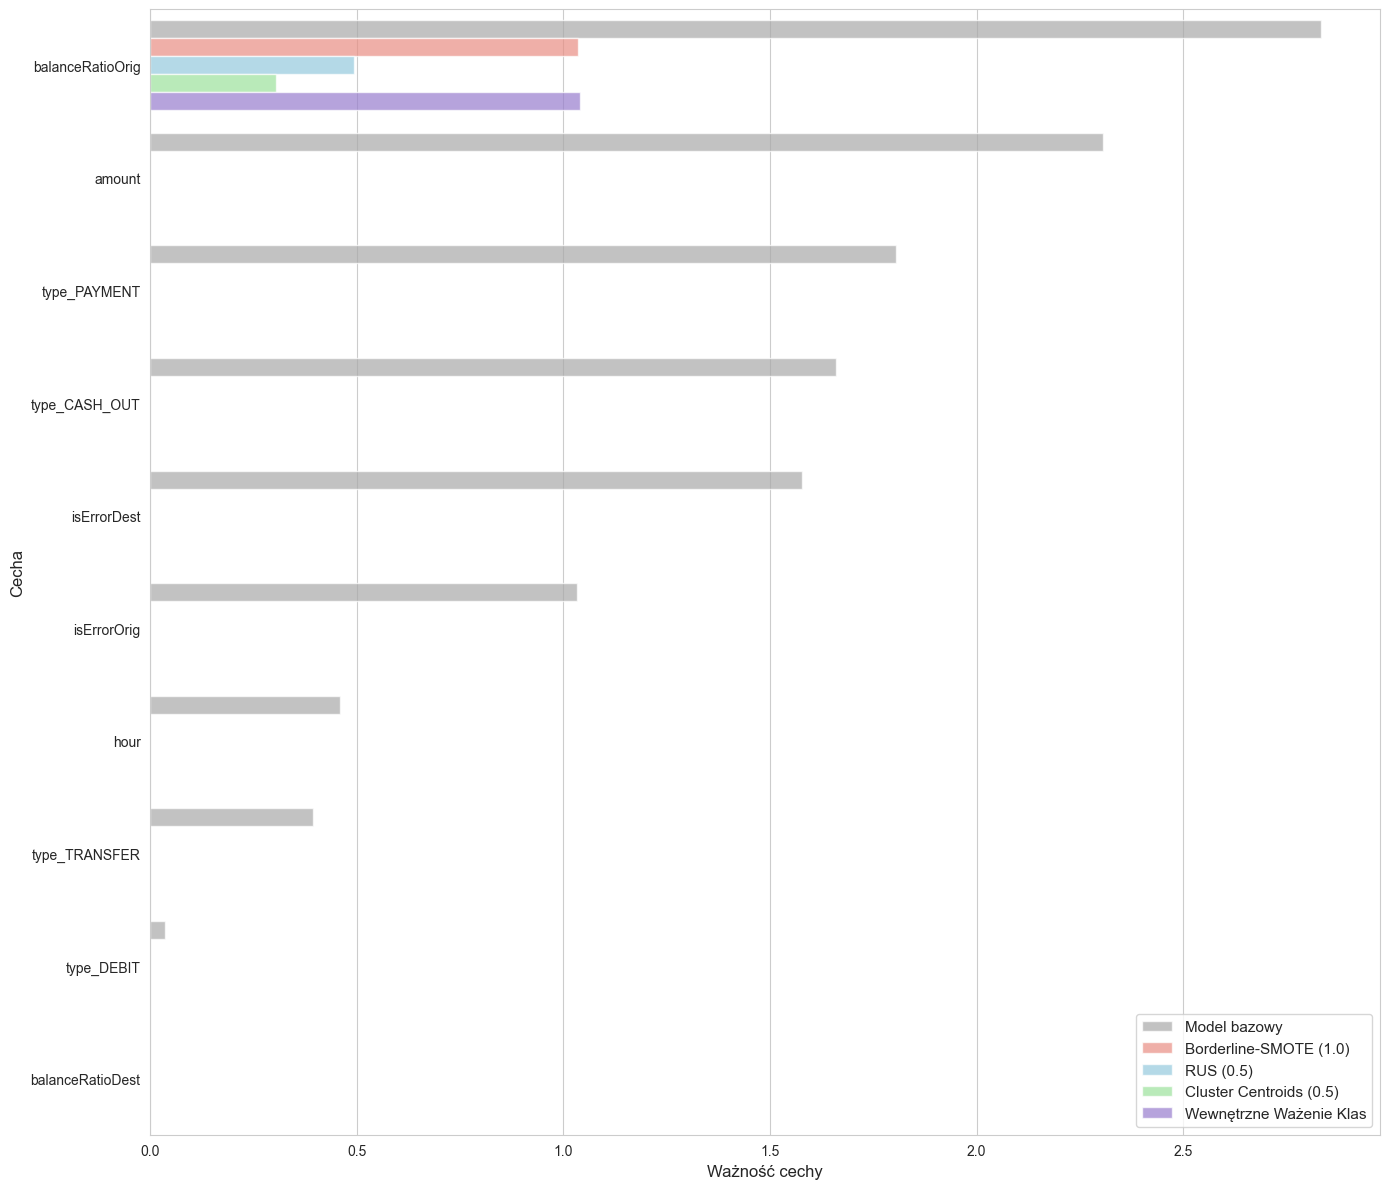

In [13]:
df_importance_lr = pd.DataFrame({
    'Cecha': nazwy_cech,
    'Model bazowy': np.abs(lr_baseline.coef_[0]),
    'Borderline-SMOTE (1.0)': np.abs(lr_bs.coef_[0]),
    'RUS (0.5)': np.abs(lr_rus.coef_[0]),
    'Cluster Centroids (0.5)': np.abs(lr_cc.coef_[0]),
    'Wewnętrzne Ważenie Klas': np.abs(lr_weighted.coef_[0])
})

df_melted_lr = df_importance_lr.melt(id_vars='Cecha', var_name='Model', value_name='Ważność')
cechy_posortowane_lr = df_importance_lr.sort_values(by='Model bazowy', ascending=False)['Cecha']

sns.set_style("whitegrid")
plt.figure(figsize=(14, 12)) 

ax = sns.barplot(
    data=df_melted_lr,
    x='Ważność',
    y='Cecha',
    hue='Model',
    order=cechy_posortowane_lr,
    palette=['darkgray', 'salmon', 'skyblue', 'lightgreen', 'mediumpurple'], 
    alpha=0.7
)

plt.xlabel('Ważność cechy', fontsize=12)
plt.ylabel('Cecha', fontsize=12)
plt.legend(fontsize=11, title_fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()


In [14]:
df_beta_raw = pd.DataFrame({
    'Cecha': X_train_scaled.columns,
    'Model bazowy': lr_baseline.coef_[0],
    'Borderline-SMOTE (1.0)': lr_bs.coef_[0],
    'RUS (0.5)': lr_rus.coef_[0],
    'Cluster Centroids (0.5)': lr_cc.coef_[0],
    'Wewnętrzne Ważenie Klas': lr_weighted.coef_[0]
})

df_beta_raw = df_beta_raw.sort_values(by='Model bazowy', key=abs, ascending=False).reset_index(drop=True)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
display(df_beta_raw)

# df_beta_raw.to_csv('tabela_beta_ze_znakiem.csv', index=False)

,Cecha,Model bazowy,Borderline-SMOTE (1.0),RUS (0.5),Cluster Centroids (0.5),Wewnętrzne Ważenie Klas
0,balanceRatioOrig,2.8347,1.0358,0.4923,0.3033,1.0390
1,amount,-2.3062,0.0002,0.0001,0.0001,0.0002
2,type_PAYMENT,-1.8054,-0.0000,-0.0000,-0.0000,-0.0000
3,type_CASH_OUT,-1.6598,0.0000,-0.0000,-0.0000,0.0000
4,isErrorDest,1.5772,-0.0000,0.0000,0.0000,-0.0000
5,isErrorOrig,1.0334,-0.0000,-0.0000,-0.0000,-0.0000
6,hour,0.4585,-0.0000,-0.0000,-0.0000,-0.0000
7,type_TRANSFER,-0.3935,-0.0000,0.0000,0.0000,0.0000
8,type_DEBIT,-0.0347,-0.0000,-0.0000,-0.0000,-0.0000
9,balanceRatioDest,0.0000,0.0000,0.0000,-0.0000,0.0000
